# 1. Le service interne

Plus aucun téléchargement. Les modèles tournent sur llm.lab.sspcloud.fr

In [6]:
import os
import subprocess

if "OPENAI_API_KEY" not in os.environ:
    r = subprocess.run(["vault", "kv", "get", "-field=OPENAI_API_KEY",
                        "onyxia-kv/farisazibert/LLM"],
                       capture_output=True, text=True)
    if r.returncode == 0 and r.stdout.strip():
        os.environ["OPENAI_API_KEY"] = r.stdout.strip()

print("cle presente :", "OPENAI_API_KEY" in os.environ)

cle presente : True


In [7]:
import base64
import io
import json
import re
import time
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import s3fs
from PIL import Image

BASE_URL = "https://llm.lab.sspcloud.fr/api"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"}

BUCKET = "projet-mesure-qualite-rp"
CAMPAGNE = "RG25"
fs = s3fs.S3FileSystem()

rep = requests.get(f"{BASE_URL}/models", headers=HEADERS, timeout=30)
rep.raise_for_status()
DISPONIBLES = [m["id"] for m in rep.json()["data"]]
for m in DISPONIBLES:
    print(m)

gemma4-26b-moe
qwen3-6-35b-moe
qwen3-vl
qwen3-embedding-8b
chandra-ocr-2
qwen3-8-27b


# Quels modèles savent regarder une image




In [8]:
def _b64(image):
    tampon = io.BytesIO()
    image.convert("RGB").save(tampon, format="PNG")
    return base64.b64encode(tampon.getvalue()).decode()


def sait_voir(nom_modele):
    petite = Image.new("RGB", (32, 32), "white")
    payload = {"model": nom_modele,
               "messages": [{"role": "user", "content": [
                   {"type": "image_url",
                    "image_url": {"url": f"data:image/png;base64,{_b64(petite)}"}},
                   {"type": "text", "text": "Reponds uniquement : OK"}]}],
               "max_tokens": 10, "temperature": 0}
    try:
        r = requests.post(f"{BASE_URL}/chat/completions", headers=HEADERS,
                          json=payload, timeout=60)
        return r.status_code == 200
    except Exception:
        return False


MULTIMODAUX = []
for m in DISPONIBLES:
    if "embedding" in m:
        print(f"{m:26} ecarte : produit des vecteurs, pas du texte")
        continue
    ok = sait_voir(m)
    print(f"{m:26} {'image acceptee' if ok else 'texte seul'}")
    if ok:
        MULTIMODAUX.append(m)

print(f"\n{len(MULTIMODAUX)} modeles utilisables : {MULTIMODAUX}")

gemma4-26b-moe             image acceptee
qwen3-6-35b-moe            image acceptee
qwen3-vl                   image acceptee
qwen3-embedding-8b         ecarte : produit des vecteurs, pas du texte
chandra-ocr-2              image acceptee
qwen3-8-27b                image acceptee

5 modeles utilisables : ['gemma4-26b-moe', 'qwen3-6-35b-moe', 'qwen3-vl', 'chandra-ocr-2', 'qwen3-8-27b']


# La fonction d'interrogation

In [10]:


def demander(image, question, modele, max_tokens=120, tentatives=3):
    """Envoie une vignette EN PLEINE RESOLUTION, renvoie le texte produit.

    Reessaie en cas d'erreur reseau : le service est partage, une requete peut
    echouer ponctuellement sans que le modele soit en cause.
    """
    payload = {"model": modele,
               "messages": [{"role": "user", "content": [
                   {"type": "image_url",
                    "image_url": {"url": f"data:image/png;base64,{_b64(image)}"}},
                   {"type": "text", "text": question}]}],
               "max_tokens": max_tokens, "temperature": 0}
    derniere = None
    for essai in range(tentatives):
        try:
            r = requests.post(f"{BASE_URL}/chat/completions", headers=HEADERS,
                              json=payload, timeout=180)
            r.raise_for_status()
            return r.json()["choices"][0]["message"]["content"].strip()
        except Exception as e:
            derniere = e
            time.sleep(2 * (essai + 1))
    raise derniere
     


# 2. Les images de bulletins

In [11]:
fichiers = [f for f in fs.find(f"{BUCKET}/data/raw/{CAMPAGNE}/BIE") if f.endswith("_BI.jpg")]
bi = pd.DataFrame({"chemin": fichiers})
bi["nom_fichier"] = bi.chemin.map(lambda c: Path(c).stem)
morceaux = bi.nom_fichier.str.split("_")
bi["numut"] = morceaux.str[0]
bi["cabarres"] = morceaux.str[1]
bi["cle"] = bi.numut + "_" + bi.cabarres
bi["dep"] = bi.chemin.str.split("/").str[6]
bi = bi.reset_index(drop=True)

print(f"{len(bi)} bulletins individuels")
print(f"{bi.dep.nunique()} departements")
print(bi.dep.value_counts().head(10).to_string())


def charger(chemin):
    with fs.open(chemin, "rb") as f:
        return Image.open(io.BytesIO(f.read())).convert("RGB")


page = charger(bi.chemin[0])
print("\ntaille de la premiere image :", page.size)

305 bulletins individuels
9 departements
dep
972    71
75     42
978    38
976    34
01     33
26     30
38     26
76     18
2B     13

taille de la premiere image : (1656, 4709)


# 3. La référence : le Fiqual de type 3

In [13]:

def lire_brut(chemin, encodage="latin-1"):
    """Une ligne du fichier = une chaine. Le separateur \x00 n'existe pas
    dans le fichier, donc pandas ne decoupe rien : indispensable ici, car le
    Fiqual mele plusieurs structures de largeurs differentes."""
    return pd.read_csv(chemin, sep="\x00", header=None, names=["ligne"], dtype=str,
                       encoding=encodage, keep_default_na=False, engine="python")["ligne"]


brut = lire_brut(f"s3://{BUCKET}/data/raw/{CAMPAGNE}/RP_PMQ_FIQUAL2599.txt")
champs_fq = brut.str.split("|")

print("structures presentes dans le fichier :")
print(pd.crosstab(champs_fq.str[0], champs_fq.str.len()).to_string())

fq3 = pd.DataFrame(champs_fq[champs_fq.str[0] == "3"].tolist(), dtype=str)
print(f"\ntype 3 : {len(fq3)} lignes, {fq3.shape[1]} colonnes")
     

structures presentes dans le fichier :
ligne  17  19   20   32   40   77
ligne                            
1       0   0    0  120    0    0
2       0   0    0    0  171    0
3       0   0    0    0    0  169
A       0   0  265    0    0    0
B       0   5    0    0    0    0
C       0   9    0    0    0    0
D      11   0    0    0    0    0

type 3 : 169 lignes, 77 colonnes


In [14]:
# La cle doit etre construite de la meme facon des deux cotes.
# On teste les positions plausibles plutot que de supposer.
for ut in range(1, 6):
    for cd in range(1, 8):
        if ut == cd:
            continue
        cles = (fq3[ut].str.strip() + "_" + fq3[cd].str.strip())
        part = bi.cle.isin(set(cles)).mean()
        if part > 0.5:
            print(f"UT={ut}, CODE={cd} -> {part:.0%} des images retrouvees")

UT=2, CODE=4 -> 55% des images retrouvees


In [15]:
POS_UT, POS_CAB = 2, 4      # <-- ajuster d'apres le test ci-dessus

fq3["cle"] = fq3[POS_UT].str.strip() + "_" + fq3[POS_CAB].str.strip()
print(f"{fq3.cle.nunique()} cles distinctes pour {len(fq3)} lignes")
print(f"doublons : {int(fq3.cle.duplicated().sum())}")
print(f"{bi.cle.isin(set(fq3.cle)).mean():.0%} des images BI ont une reference")

169 cles distinctes pour 169 lignes
doublons : 0
55% des images BI ont une reference


# Les colonnes candidates

Les trois cellules suivantes proposent des candidats pour chaque variable. Lis les listes, puis remplis COLS.


In [19]:


def borne(col, lo, hi, part_min=0.98):
    v = fq3[col].str.strip()
    v = v[v.str.fullmatch(r"\d{1,4}") == True]
    if len(v) < 10:
        return False
    return bool(v.astype(int).between(lo, hi).mean() > part_min)


colonnes = [c for c in fq3.columns if c != "cle"]

print("candidats jour   :", [c for c in colonnes if borne(c, 1, 31)])
print("candidats mois   :", [c for c in colonnes if borne(c, 1, 12)])
print("candidats annee  :", [c for c in colonnes if borne(c, 1890, 2030)])
     


candidats jour   : [0, 13, 14, 15, 26, 27, 32, 42, 43, 45, 46, 47, 48, 49, 50, 52, 55, 67, 68, 69, 71, 74, 75]
candidats mois   : [0, 13, 15, 26, 27, 32, 42, 43, 45, 46, 47, 48, 49, 50, 52, 55, 67, 68, 69, 71, 74, 75]
candidats annee  : [16]


In [20]:
# Sexe : uniquement 1 et 2, et une repartition proche de 50/50.
# C'est la repartition qui distingue le sexe d'une question oui/non.
print("candidats sexe (colonne, part de '1', effectif) :")
cands = []
for c in colonnes:
    v = fq3[c].str.strip()
    v = v[v != ""]
    if not v.empty and set(v.unique()) <= {"1", "2"}:
        cands.append((c, round((v == "1").mean(), 3), len(v)))
for t in sorted(cands, key=lambda t: abs(t[1] - 0.5)):
    print("  ", t)
     

candidats sexe (colonne, part de '1', effectif) :
   (49, np.float64(0.483), 60)
   (13, np.float64(0.621), 169)
   (42, np.float64(0.315), 130)
   (48, np.float64(0.305), 105)
   (55, np.float64(0.769), 52)
   (27, np.float64(0.9), 10)
   (74, np.float64(0.933), 45)
   (26, np.float64(0.056), 142)


In [21]:
# Nom et prenom : colonnes alphabetiques avec beaucoup de valeurs distinctes.
print("colonnes alphabetiques :")
for c in colonnes:
    v = fq3[c].str.strip()
    v = v[v != ""]
    if v.empty:
        continue
    part_alpha = v.str.fullmatch(r"[A-Za-z' \-]+").mean()
    if part_alpha > 0.9 and v.nunique() > 20:
        print(f"  colonne {c:3} — {v.nunique():4} valeurs distinctes, "
              f"remplissage {(fq3[c].str.strip() != '').mean():.0%}, "
              f"exemples : {list(v.head(3))}")

colonnes alphabetiques :
  colonne  11 —  136 valeurs distinctes, remplissage 99%, exemples : ['COTIER', 'VION', 'DURAND']
  colonne  12 —  105 valeurs distinctes, remplissage 99%, exemples : ['EMILE', 'LOUISE', 'PAUL']
  colonne  38 —   38 valeurs distinctes, remplissage 43%, exemples : ['GRAND COMORES', 'AUCHAN', 'GUADELOUPE']
  colonne  40 —   44 valeurs distinctes, remplissage 41%, exemples : ['CARREFOUR', 'IRLANDE', 'MARQUISES']
  colonne  53 —   50 valeurs distinctes, remplissage 33%, exemples : ['GARAGE SANTIER', 'MAISON FRANCE CONFORT', 'GARAGE RENAULT']
  colonne  54 —   48 valeurs distinctes, remplissage 33%, exemples : ['REPARATION AUTO', 'DIRECTEUR D AGENCE', 'REPARATION AUTOMOBILE']
  colonne  60 —   39 valeurs distinctes, remplissage 29%, exemples : ['PASTEUR', 'DES BOIS', 'DU PERE RAMBRANDT']
  colonne  70 —   41 valeurs distinctes, remplissage 30%, exemples : ['OUVRIER', 'RESPONSABLE D AGENCE', 'TECHNICIEN']


In [23]:
COLS = {
    "NOM":    11,
    "PRENOM": 12,
    "SEXE":   13,
    "JOUR":   14,
    "MOIS":   15,
    "ANNEE":  16,
}

COLS = {k: v for k, v in COLS.items() if v is not None}

if not COLS:
    print("renseigner COLS avant de continuer")
else:
    REFERENCE = fq3[["cle"] + list(COLS.values())].copy()
    REFERENCE.columns = ["cle"] + [f"ref_{k}" for k in COLS]
    for c in REFERENCE.columns[1:]:
        REFERENCE[c] = REFERENCE[c].str.strip()
    print(f"{len(COLS)} colonnes retenues\n")
    print(REFERENCE.head(5).to_string(index=False))

6 colonnes retenues

            cle ref_NOM ref_PRENOM ref_SEXE ref_JOUR ref_MOIS ref_ANNEE
9711_5300000473  COTIER      EMILE        1       17       06      1987
7601_5300000394    VION     LOUISE        2       03       04      1951
9761_5300000048  DURAND       PAUL        1       01       01      1980
9711_5300000508  GNEMET     JULIEN        1       27       04      1983
9761_5300000189    LEON       PAUL        1       08       12      1999


# La vérification qui démontre

In [24]:
CHEMIN_PRENOMS = f"s3://{BUCKET}/documentation/Dictionnaires/dico_prenom2027_base2023.txt"

try:
    dico = pd.read_csv(CHEMIN_PRENOMS, sep="|", dtype=str, encoding="latin-1",
                       keep_default_na=False)
    SEXE_DU_PRENOM = dict(zip(dico.iloc[:, 0].str.upper().str.strip(),
                              dico.iloc[:, 1].str.strip()))
    print(f"{len(SEXE_DU_PRENOM)} prenoms dans le dictionnaire")
except Exception as e:
    SEXE_DU_PRENOM = {}
    print("dictionnaire indisponible :", type(e).__name__, e)

if SEXE_DU_PRENOM and "PRENOM" in COLS and "SEXE" in COLS:
    v = fq3[[COLS["PRENOM"], COLS["SEXE"]]].copy()
    v.columns = ["prenom", "sexe"]
    v = v[(v.prenom.str.strip() != "") & (v.sexe.str.strip() != "")]
    v["sexe_dico"] = v.prenom.str.upper().str.strip().map(SEXE_DU_PRENOM)
    connus = v.dropna(subset=["sexe_dico"])
    print(f"{len(connus)} prenoms retrouves")
    if len(connus):
        accord = (connus.sexe.str.strip() == connus.sexe_dico).mean()
        print(f"accord sexe Fiqual / dictionnaire : {accord:.1%}")
        if accord > 0.95:
            print("→ les deux colonnes sont confirmees")
        elif accord < 0.2:
            print("→ colonnes probablement inversees")
        else:
            print("→ au moins une des deux colonnes est fausse")

12125 prenoms dans le dictionnaire
161 prenoms retrouves
accord sexe Fiqual / dictionnaire : 91.9%
→ au moins une des deux colonnes est fausse


# 4. Caler les zones sur l'image

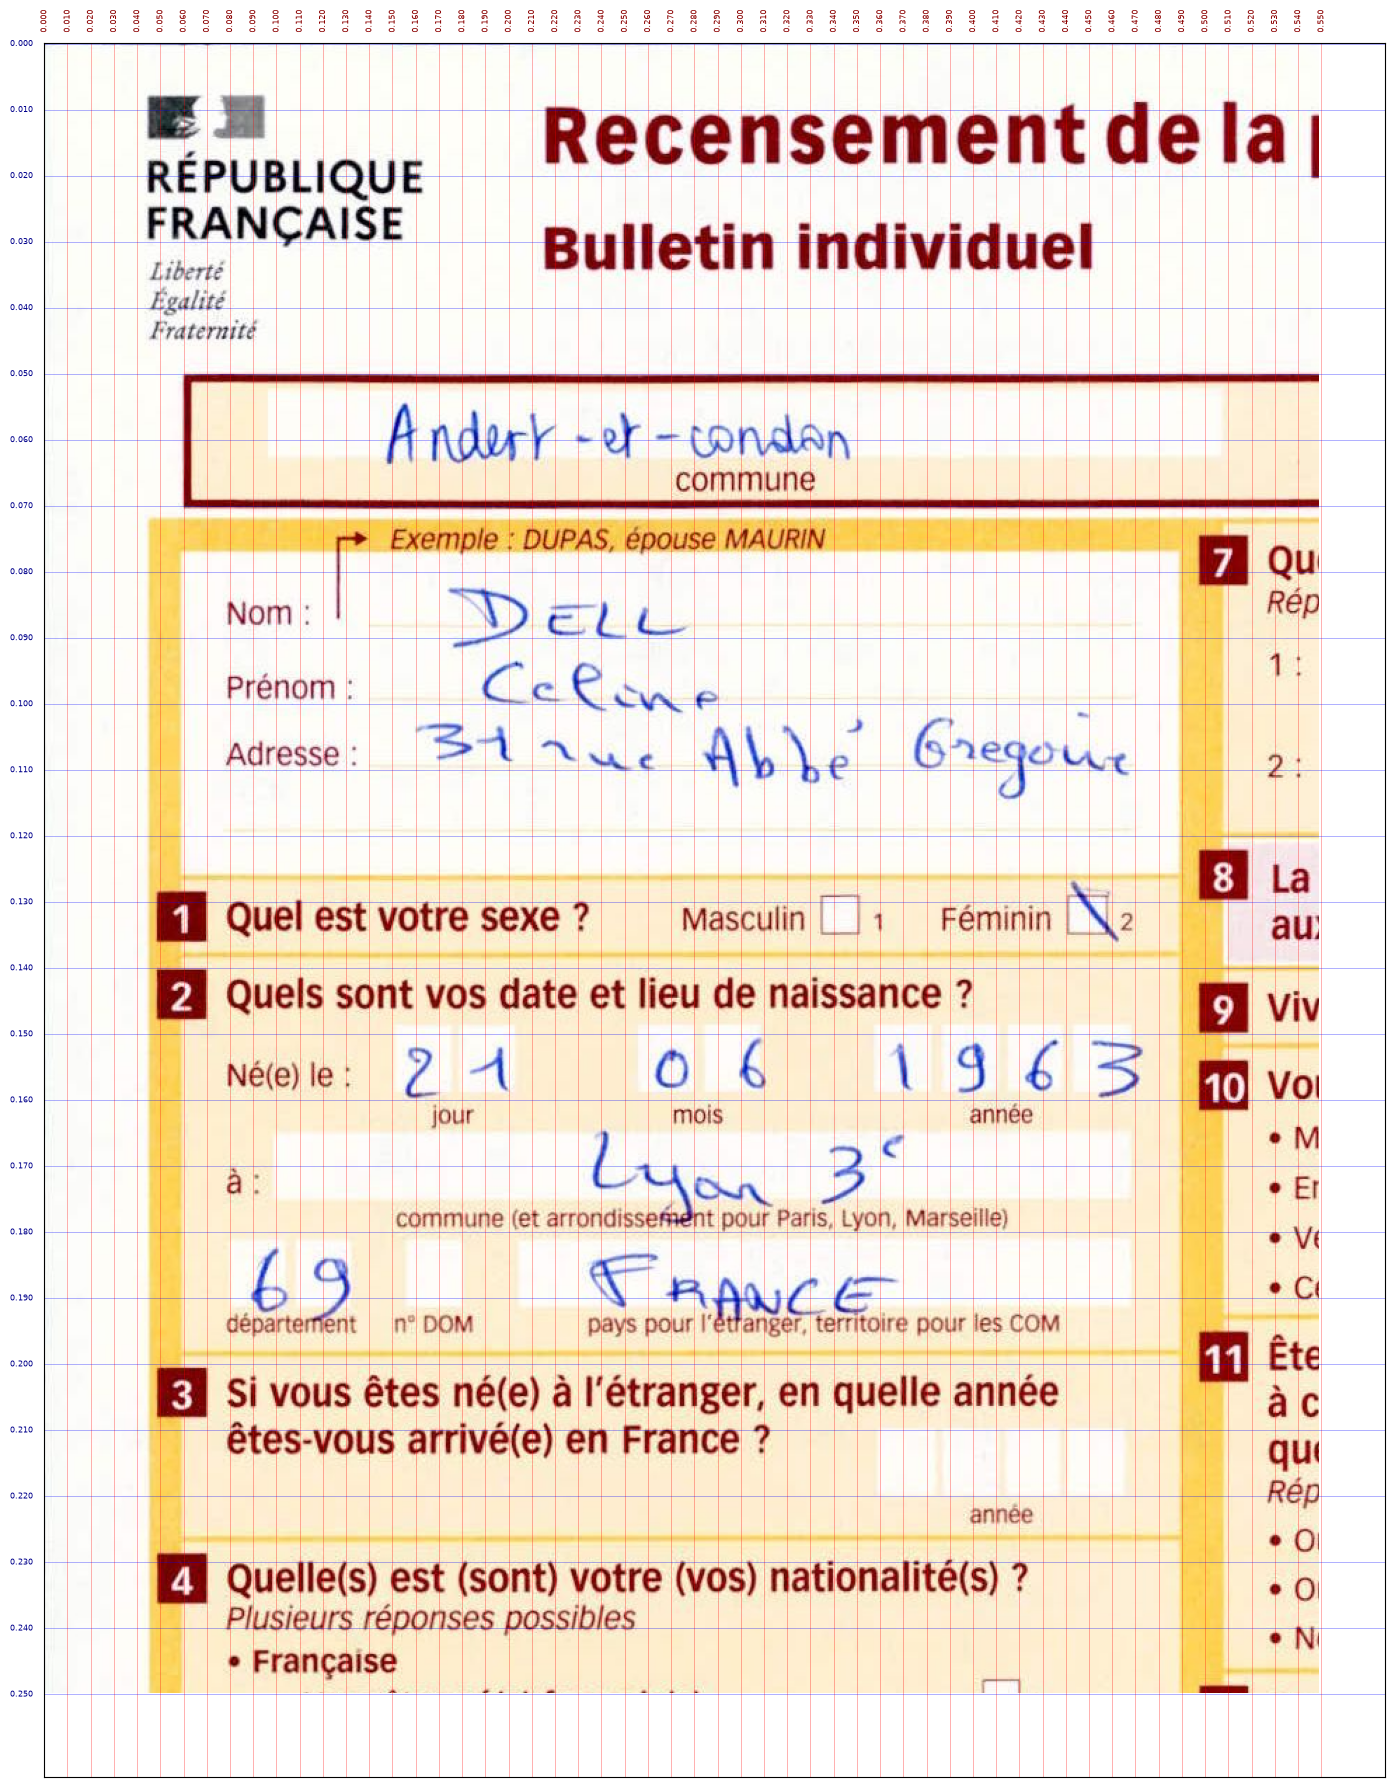

In [26]:
def grille(image, x0=0.0, y0=0.0, x1=0.55, y1=0.25, pas=0.01, taille=14):
    """Affiche une portion de l'image avec une grille graduee en fractions.

    x0, y0, x1, y1 : la portion affichee, en fractions de l'image entiere.
    pas            : l'ecart entre deux graduations.
    """
    L, H = image.size
    box = (int(x0 * L), int(y0 * H), int(x1 * L), int(y1 * H))
    vue = image.crop(box)

    fig, ax = plt.subplots(figsize=(taille, taille * vue.size[1] / max(vue.size[0], 1)))
    ax.imshow(vue)

    for i in range(int(round((x1 - x0) / pas)) + 1):
        fx = x0 + i * pas
        px = fx * L - box[0]
        ax.axvline(px, color="red", lw=0.4, alpha=0.55)
        ax.text(px, -8, f"{fx:.3f}", fontsize=6, rotation=90,
                ha="center", va="bottom", color="darkred")
    for j in range(int(round((y1 - y0) / pas)) + 1):
        fy = y0 + j * pas
        py = fy * H - box[1]
        ax.axhline(py, color="blue", lw=0.4, alpha=0.55)
        ax.text(-8, py, f"{fy:.3f}", fontsize=6, ha="right",
                va="center", color="darkblue")

    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()


# Vue d'ensemble du coin haut gauche du recto
grille(page, x0=0.0, y0=0.0, x1=0.55, y1=0.25, pas=0.01)
     

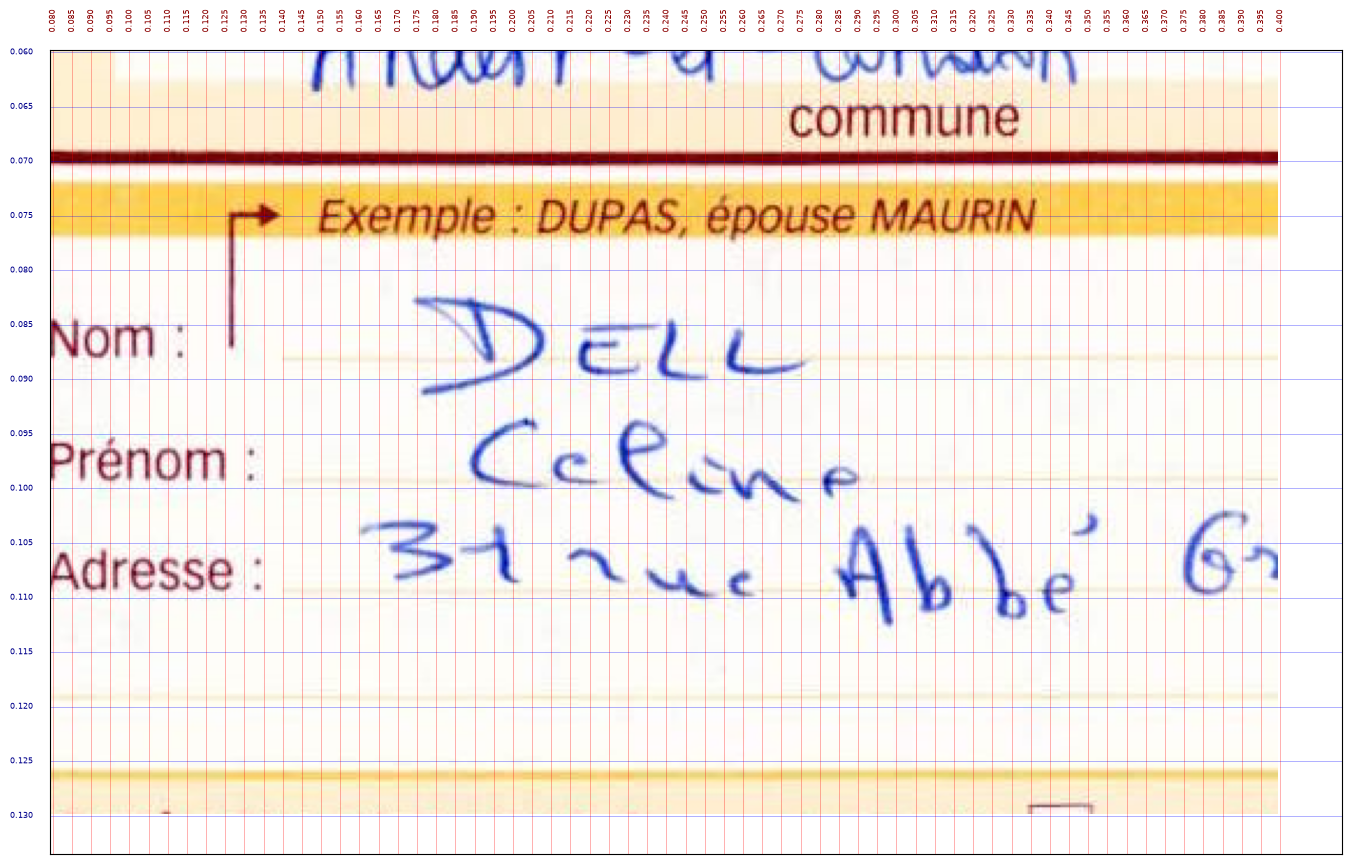

In [27]:
# Zoom sur le bloc nom / prenom. Ajuster les bornes d'apres la vue d'ensemble.
grille(page, x0=0.08, y0=0.06, x1=0.40, y1=0.13, pas=0.005)

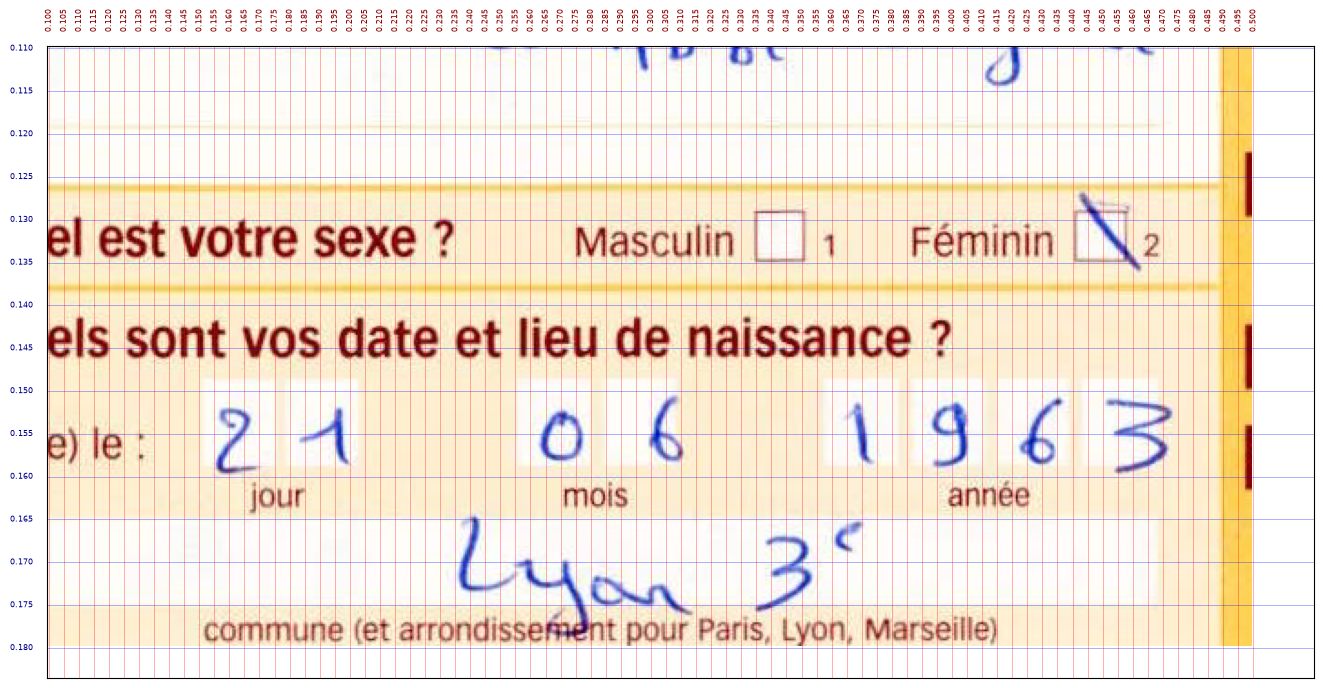

In [28]:


# Zoom sur le sexe et la date de naissance. Ajuster les bornes.
grille(page, x0=0.10, y0=0.11, x1=0.50, y1=0.18, pas=0.005)
     


# Noter les bords

Pour chaque champ, quatre nombres lus sur la grille : gauche, haut, droite, bas.

In [53]:
# (gauche, haut, droite, bas) en fractions de l'image entiere
BORDS = {
    "NOM":    (0.155, 0.083, 0.400, 0.094),
    "PRENOM": (0.155, 0.094, 0.400, 0.102),
    "SEXE_M": (0.330, 0.128, 0.355, 0.140),
    "SEXE_F": (0.435, 0.128, 0.465, 0.140),
    "JOUR":   (0.155, 0.150, 0.215, 0.161),
    "MOIS":   (0.240, 0.148, 0.320, 0.161),
    "ANNEE":  (0.315, 0.148, 0.480, 0.161),
}

ZONES = {k: (g, h, round(d - g, 4), round(b - h, 4))
         for k, (g, h, d, b) in BORDS.items()
         if (d - g) > 0 and (b - h) > 0}

if not ZONES:
    print("reporter les valeurs lues sur les grilles ci-dessus")
else:
    for k, z in ZONES.items():
        print(f"{k:8} x={z[0]:.3f}  y={z[1]:.3f}  l={z[2]:.3f}  h={z[3]:.3f}")
     

NOM      x=0.155  y=0.083  l=0.245  h=0.011
PRENOM   x=0.155  y=0.094  l=0.245  h=0.008
SEXE_M   x=0.330  y=0.128  l=0.025  h=0.012
SEXE_F   x=0.435  y=0.128  l=0.030  h=0.012
JOUR     x=0.155  y=0.150  l=0.060  h=0.011
MOIS     x=0.240  y=0.148  l=0.080  h=0.013
ANNEE    x=0.315  y=0.148  l=0.165  h=0.013


NOM — 406 x 52 pixels


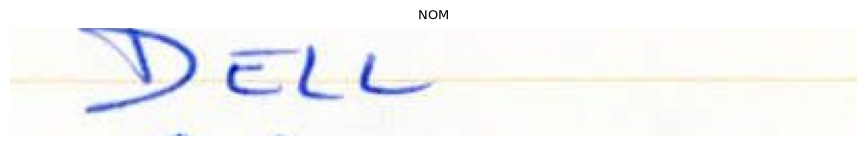

PRENOM — 406 x 38 pixels


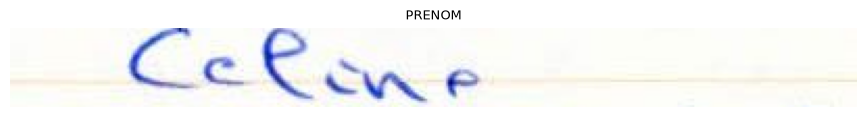

SEXE_M — 41 x 57 pixels


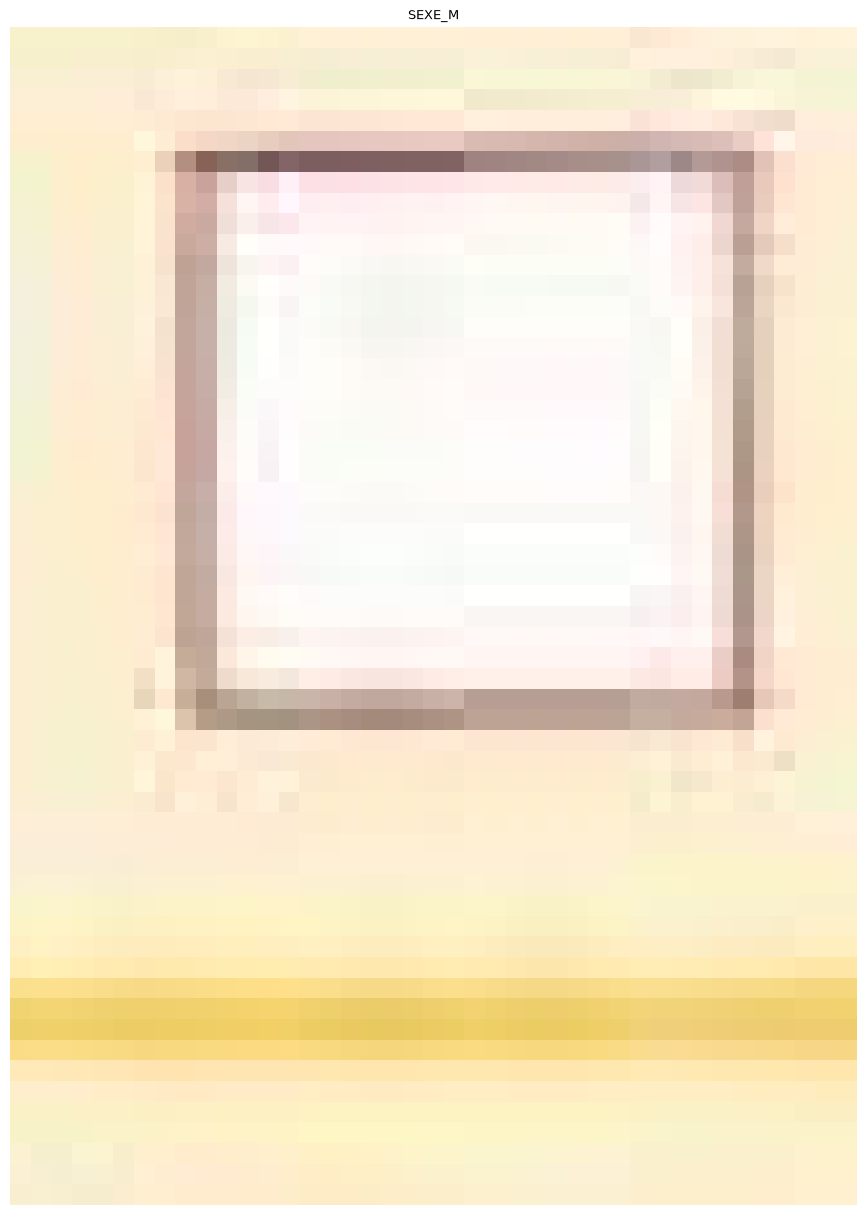

SEXE_F — 50 x 57 pixels


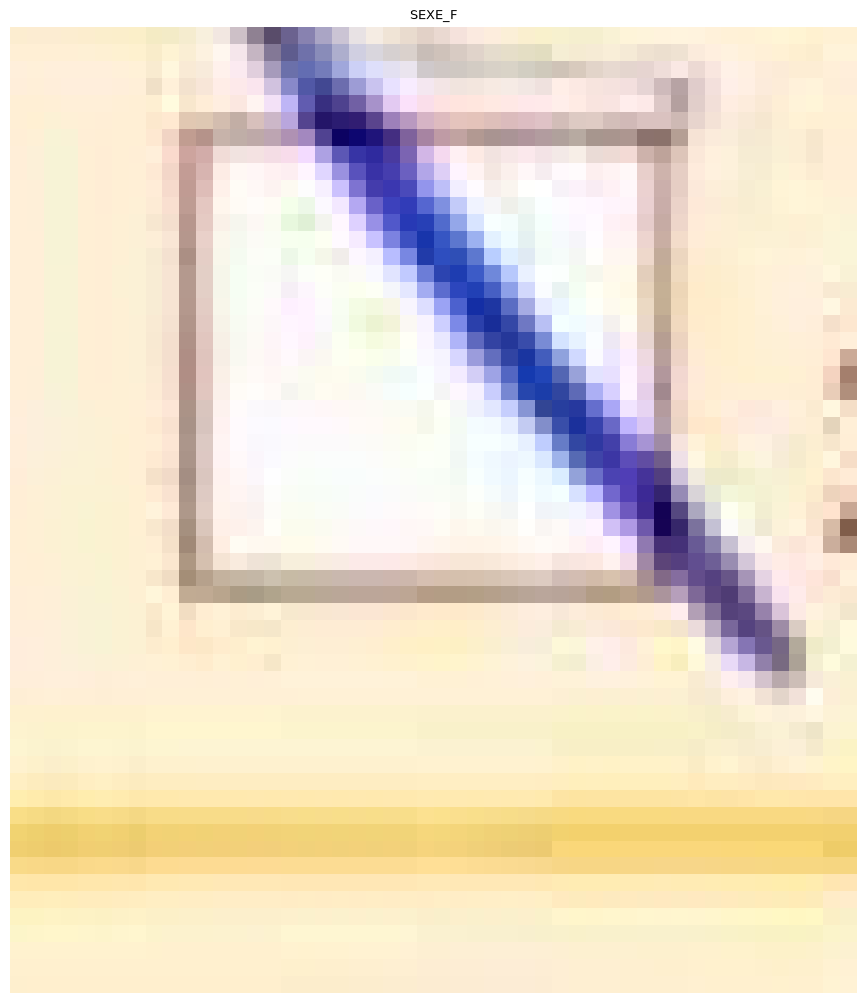

JOUR — 100 x 52 pixels


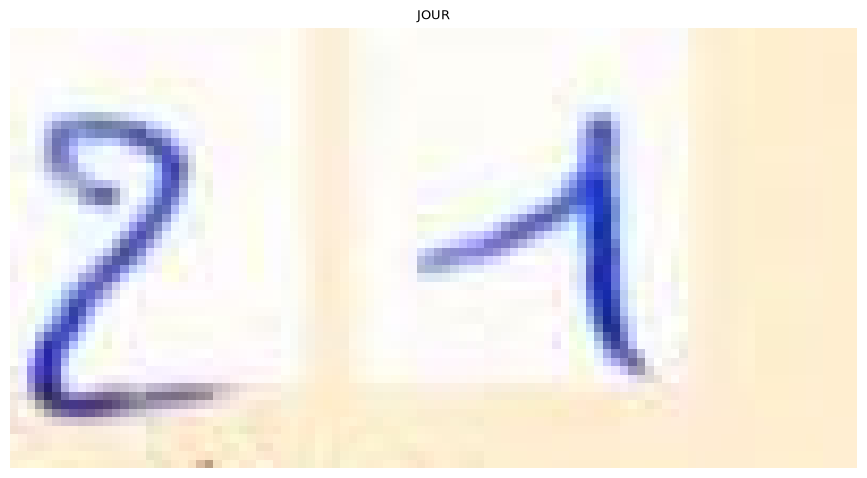

MOIS — 132 x 62 pixels


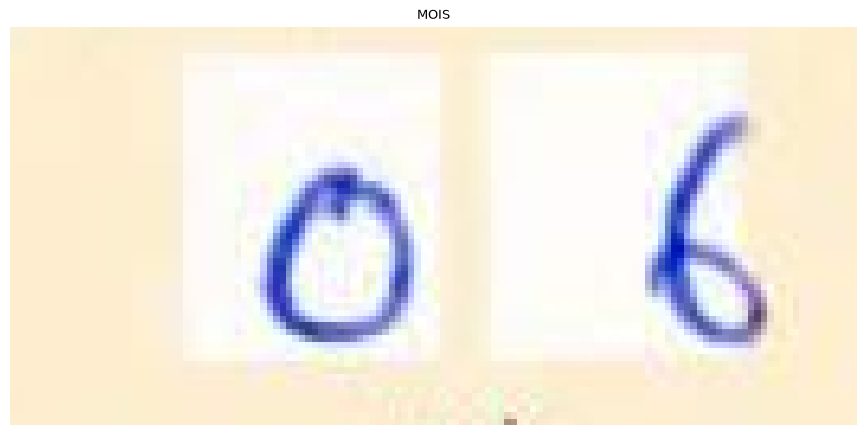

ANNEE — 273 x 62 pixels


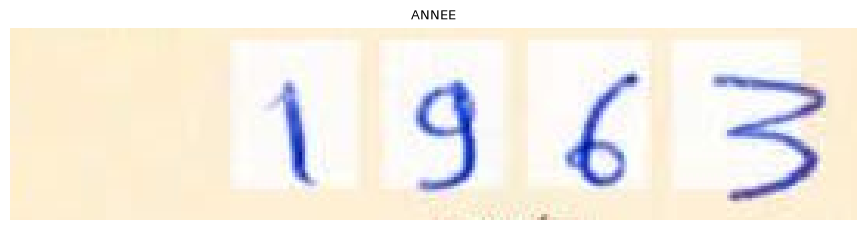

In [54]:
def decouper_frac(image, zone):
    """Decoupe une zone exprimee en fractions, en pleine resolution."""
    L, H = image.size
    x, y, w, h = zone
    return image.crop((int(x * L), int(y * H), int((x + w) * L), int((y + h) * H)))


for nom_zone, zone in ZONES.items():
    v = decouper_frac(page, zone)
    print(f"{nom_zone} — {v.size[0]} x {v.size[1]} pixels")
    fig, ax = plt.subplots(figsize=(11, 11 * v.size[1] / max(v.size[0], 1)))
    ax.imshow(v)
    ax.set_title(nom_zone, fontsize=9)
    plt.axis("off")
    plt.show()

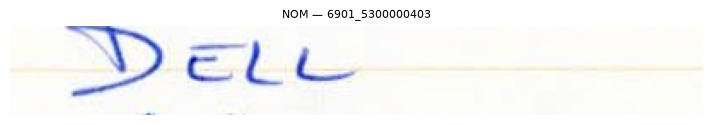

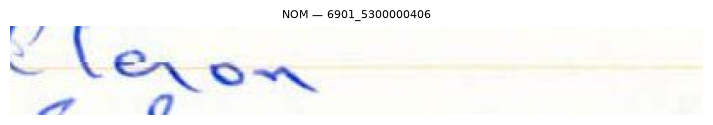

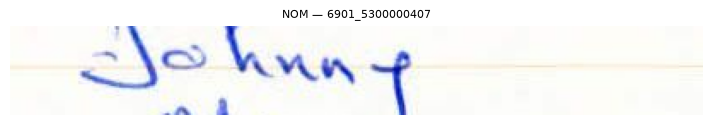

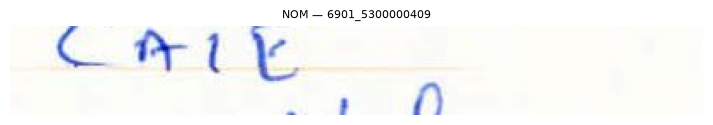

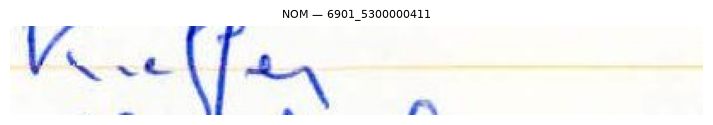

In [55]:
# Verifier le calage sur plusieurs bulletins : un cadrage juste sur un document
# peut deriver sur un autre.
CHAMP_A_VERIFIER = "NOM"

if CHAMP_A_VERIFIER in ZONES:
    for i in range(min(5, len(bi))):
        im = charger(bi.chemin[i])
        v = decouper_frac(im, ZONES[CHAMP_A_VERIFIER])
        fig, ax = plt.subplots(figsize=(9, 9 * v.size[1] / max(v.size[0], 1)))
        ax.imshow(v)
        ax.set_title(f"{CHAMP_A_VERIFIER} — {bi.cle[i]}", fontsize=8)
        plt.axis("off")
        plt.show()

In [56]:
# Enregistrer la configuration : un fichier par campagne, lisible par un humain.
if ZONES:
    Path("configs").mkdir(exist_ok=True)
    chemin_conf = f"configs/positions_BI_{CAMPAGNE}.json"
    config = {
        "campagne": CAMPAGNE,
        "zone": "BI",
        "page": "recto, coin haut gauche",
        "unite": "fractions de l'image entiere",
        "format": "x, y, largeur, hauteur",
        "releve_sur": bi.cle[0],
        "taille_image_reference": list(page.size),
        "zones": {k: list(v) for k, v in ZONES.items()},
        "methode": {"SEXE_M": "densite", "SEXE_F": "densite",
                    "JOUR": "modele", "MOIS": "modele", "ANNEE": "modele",
                    "NOM": "modele", "PRENOM": "modele"},
    }
    with open(chemin_conf, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2, ensure_ascii=False)
    print("enregistre dans", chemin_conf)

enregistre dans configs/positions_BI_RG25.json


# 5. Le sexe, sans modèle

In [58]:
def densite(vignette, marge=0.18, seuil_gris=140):
    """Part de pixels sombres au centre de la case, hors bordure imprimee."""
    a = np.array(vignette.convert("L"), dtype=float)
    h, w = a.shape
    mh, mw = int(h * marge), int(w * marge)
    interieur = a[mh:h - mh, mw:w - mw]
    return float((interieur < seuil_gris).mean())


SEUIL_COCHE = 0.08


def lire_sexe(image):
    """Renvoie ('1', '2' ou '') et les deux densites mesurees."""
    if "SEXE_M" not in ZONES or "SEXE_F" not in ZONES:
        return "", []
    d = [densite(decouper_frac(image, ZONES["SEXE_M"])),
         densite(decouper_frac(image, ZONES["SEXE_F"]))]
    coches = [i + 1 for i, x in enumerate(d) if x > SEUIL_COCHE]
    return (str(coches[0]) if len(coches) == 1 else ""), [round(x, 3) for x in d]


if "SEXE_M" in ZONES:
    for i in range(min(8, len(bi))):
        im = charger(bi.chemin[i])
        val, dens = lire_sexe(im)
        print(f"{bi.cle[i]:24} sexe={val!r:4} densites={dens}")

6901_5300000403          sexe='2'  densites=[0.0, 0.083]
6901_5300000406          sexe='2'  densites=[0.001, 0.175]
6901_5300000407          sexe='2'  densites=[0.024, 0.176]
6901_5300000409          sexe=''   densites=[0.005, 0.069]
6901_5300000411          sexe='2'  densites=[0.026, 0.179]
6901_5300000413          sexe='2'  densites=[0.02, 0.15]
6901_5300000416          sexe=''   densites=[0.0, 0.001]
6901_5300000417          sexe=''   densites=[0.029, 0.02]


# 6. Les questions posées aux modèles

In [60]:
PROMPT_LIGNE = """Cette image montre une seule ligne manuscrite extraite d'un formulaire
administratif francais : un {champ} ecrit a la main, en majuscules d'imprimerie.

Transcris exactement ce qui est ecrit, en MAJUSCULES, sans accent.
Ne corrige rien, n'ajoute rien, ne devine pas.
Si l'ecriture n'est pas lisible avec certitude, reponds exactement : ILLISIBLE

Reponds uniquement par la transcription, sans phrase ni commentaire."""


PROMPT_CHIFFRES = """Cette image montre {n} chiffres manuscrits ecrits dans des cases
imprimees, extraits d'un formulaire administratif francais.
Il s'agit du {champ} d'une date de naissance.

Transcris uniquement les chiffres, colles, sans espace ni separateur.
Ne devine pas : si un chiffre n'est pas lisible avec certitude, reponds exactement : ILLISIBLE

Reponds uniquement par les chiffres, sans phrase ni commentaire."""


CHAMPS = {
    "NOM":    PROMPT_LIGNE.format(champ="nom de famille"),
    "PRENOM": PROMPT_LIGNE.format(champ="prenom"),
    "JOUR":   PROMPT_CHIFFRES.format(n="deux", champ="jour"),
    "MOIS":   PROMPT_CHIFFRES.format(n="deux", champ="mois"),
    "ANNEE":  PROMPT_CHIFFRES.format(n="quatre", champ="annee"),
}

CHAMPS = {k: v for k, v in CHAMPS.items() if k in ZONES and k in COLS}
print("champs qui seront lus par les modeles :", list(CHAMPS))

champs qui seront lus par les modeles : ['NOM', 'PRENOM', 'JOUR', 'MOIS', 'ANNEE']


# 7. Comparer une lecture à la référence

In [62]:
def normaliser(t):
    """Majuscules, sans accent, espaces ecrases : le format du Fiqual."""
    if t is None:
        return ""
    t = unicodedata.normalize("NFKD", str(t).strip())
    t = "".join(c for c in t if not unicodedata.combining(c)).upper()
    t = re.sub(r"[^A-Z0-9 ]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


def distance(a, b):
    """Distance d'edition : nombre de caracteres a changer pour passer de a a b."""
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prec = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cour = [i]
        for j, cb in enumerate(b, 1):
            cour.append(min(prec[j] + 1, cour[j - 1] + 1, prec[j - 1] + (ca != cb)))
        prec = cour
    return prec[-1]


MARQUEURS_ILLISIBLE = ("ILLISIBLE", "UNREADABLE", "NON LISIBLE", "INCONNU")


def classer(lu, ref):
    """Renvoie 'exact', 'illisible' ou 'invente'."""
    l, r = normaliser(lu), normaliser(ref)
    if l == "" or any(m in l for m in MARQUEURS_ILLISIBLE):
        return "illisible"
    return "exact" if l == r else "invente"


for a, b in [("Élodie", "ELODIE"), ("DUPONT ", "DUPONT"), ("Jean-Luc", "JEAN LUC"),
             ("ILLISIBLE", "MARTIN"), ("MARTAN", "MARTIN")]:
    print(f"{a!r:14} vs {b!r:10} -> {classer(a, b)}")

'Élodie'       vs 'ELODIE'   -> exact
'DUPONT '      vs 'DUPONT'   -> exact
'Jean-Luc'     vs 'JEAN LUC' -> exact
'ILLISIBLE'    vs 'MARTIN'   -> illisible
'MARTAN'       vs 'MARTIN'   -> invente


# 8. Le banc d'essai

In [75]:
N = 169   # nombre de bulletins. Chaque champ est un appel : commencer petit.

ECHANTILLON = (bi.merge(REFERENCE, on="cle", how="inner")
               .head(N).reset_index(drop=True)) if COLS else bi.head(0)
print(f"{len(ECHANTILLON)} bulletins avec reference")

VIGNETTES = []
for _, r in ECHANTILLON.iterrows():
    im = charger(r.chemin)
    VIGNETTES.append({k: decouper_frac(im, ZONES[k]) for k in CHAMPS})
print(f"{len(VIGNETTES)} jeux de vignettes prepares")
print(f"{len(VIGNETTES) * len(CHAMPS)} appels par modele")

169 bulletins avec reference
169 jeux de vignettes prepares
845 appels par modele


In [76]:
def passer_examen(modele):
    """Lit tous les champs des N bulletins avec un modele. Renvoie (details, resume)."""
    lignes = []
    t0 = time.time()
    n_appels = 0

    for i, r in ECHANTILLON.iterrows():
        ligne = {"cle": r.cle, "modele": modele}
        for champ, prompt in CHAMPS.items():
            ref = r.get(f"ref_{champ}", "")
            try:
                lu = demander(VIGNETTES[i][champ], prompt, modele)
                n_appels += 1
            except Exception as e:
                lu = f"ERREUR {type(e).__name__}"
            ligne[f"lu_{champ}"] = lu
            ligne[f"ref_{champ}"] = ref
            ligne[f"etat_{champ}"] = classer(lu, ref)
            ligne[f"dist_{champ}"] = distance(normaliser(lu), normaliser(ref))
            ligne[f"len_{champ}"] = len(normaliser(ref))
        lignes.append(ligne)
        if (i + 1) % 5 == 0:
            print(f"  {i + 1}/{len(ECHANTILLON)} bulletins — {time.time() - t0:.0f} s")

    duree = time.time() - t0
    details = pd.DataFrame(lignes)

    resume = {"modele": modele,
              "secondes_par_champ": duree / max(n_appels, 1),
              "N_bulletins": len(details)}
    for champ in CHAMPS:
        etats = details[f"etat_{champ}"]
        resume[f"{champ}_exact"] = (etats == "exact").mean()
        resume[f"{champ}_illisible"] = (etats == "illisible").mean()
        resume[f"{champ}_invente"] = (etats == "invente").mean()
        lisibles = details[etats != "illisible"]
        total = lisibles[f"len_{champ}"].sum()
        resume[f"{champ}_cer"] = (lisibles[f"dist_{champ}"].sum() / total
                                  if total else float("nan"))
    return details, resume

In [77]:
#MODELES = list(MULTIMODAUX)
MODELES=['gemma4-26b-moe', 'qwen3-vl', 'chandra-ocr-2']
print("modeles compares :", MODELES)

modeles compares : ['gemma4-26b-moe', 'qwen3-vl', 'chandra-ocr-2']


In [78]:
import mlflow

mlflow.set_experiment("fiqual-banc-essai")

resultats = []
details_par_modele = {}

for modele in MODELES:
    print("\n" + "=" * 60)
    print(modele)
    print("=" * 60)
    try:
        details, resume = passer_examen(modele)
        details_par_modele[modele] = details
        resultats.append(resume)

        with mlflow.start_run(run_name=f"bi-{modele}"):
            mlflow.log_params({"modele": modele, "mode": "service interne",
                               "campagne": CAMPAGNE, "zone": "BI",
                               "N": len(details), "champs": ",".join(CHAMPS),
                               "resolution": "vignette pleine resolution"})
            mlflow.log_metrics({k: float(v) for k, v in resume.items()
                                if k != "modele" and pd.notna(v)})
            for champ, prompt in CHAMPS.items():
                mlflow.log_text(prompt, f"prompt_{champ}.txt")
            fichier = f"details_bi_{modele.replace('/', '_')}.csv"
            details.to_csv(fichier, index=False)
            mlflow.log_artifact(fichier)

        for champ in CHAMPS:
            print(f"  {champ:8} exact {resume[f'{champ}_exact']:.0%} | "
                  f"illisible {resume[f'{champ}_illisible']:.0%} | "
                  f"invente {resume[f'{champ}_invente']:.0%}")
        print(f"  {resume['secondes_par_champ']:.1f} s par champ")
    except Exception as e:
        print("ECHEC :", type(e).__name__, e)
        resultats.append({"modele": modele, "erreur": f"{type(e).__name__}: {e}"})

print("\ncampagne terminee")


gemma4-26b-moe
  5/169 bulletins — 10 s
  10/169 bulletins — 20 s
  15/169 bulletins — 30 s
  20/169 bulletins — 40 s
  25/169 bulletins — 51 s
  30/169 bulletins — 61 s
  35/169 bulletins — 72 s
  40/169 bulletins — 83 s
  45/169 bulletins — 94 s
  50/169 bulletins — 104 s
  55/169 bulletins — 115 s
  60/169 bulletins — 125 s
  65/169 bulletins — 136 s
  70/169 bulletins — 147 s
  75/169 bulletins — 157 s
  80/169 bulletins — 168 s
  85/169 bulletins — 179 s
  90/169 bulletins — 189 s
  95/169 bulletins — 200 s
  100/169 bulletins — 211 s
  105/169 bulletins — 222 s
  110/169 bulletins — 232 s
  115/169 bulletins — 243 s
  120/169 bulletins — 254 s
  125/169 bulletins — 264 s
  130/169 bulletins — 275 s
  135/169 bulletins — 285 s
  140/169 bulletins — 296 s
  145/169 bulletins — 306 s
  150/169 bulletins — 317 s
  155/169 bulletins — 327 s
  160/169 bulletins — 338 s
  165/169 bulletins — 348 s
🏃 View run bi-gemma4-26b-moe at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/

# 9. Le tableau et le graphique

In [79]:
banc = pd.DataFrame(resultats)

lignes = []
for _, r in banc.iterrows():
    for champ in CHAMPS:
        if f"{champ}_exact" in r and pd.notna(r.get(f"{champ}_exact")):
            lignes.append({
                "modele": r.modele, "champ": champ,
                "exact_%": round(r[f"{champ}_exact"] * 100, 1),
                "illisible_%": round(r[f"{champ}_illisible"] * 100, 1),
                "invente_%": round(r[f"{champ}_invente"] * 100, 1),
                "CER_%": (round(r[f"{champ}_cer"] * 100, 1)
                          if pd.notna(r[f"{champ}_cer"]) else None),
                "s_par_champ": round(r.secondes_par_champ, 1),
            })

tableau = pd.DataFrame(lignes)
tableau.to_csv("banc_bi.csv", index=False)
tableau
     

,modele,champ,exact_%,illisible_%,invente_%,CER_%,s_par_champ
0,gemma4-26b-moe,NOM,58.6,1.8,39.6,12.6,0.4
1,gemma4-26b-moe,PRENOM,68.0,0.6,31.4,11.6,0.4
2,gemma4-26b-moe,JOUR,70.4,1.2,28.4,16.3,0.4
3,gemma4-26b-moe,MOIS,85.2,1.2,13.6,8.9,0.4
4,gemma4-26b-moe,ANNEE,83.4,1.8,14.8,7.6,0.4
5,qwen3-vl,NOM,42.6,19.5,37.9,16.5,0.4
6,qwen3-vl,PRENOM,65.7,7.7,26.6,10.2,0.4
7,qwen3-vl,JOUR,67.5,4.7,27.8,14.6,0.4
8,qwen3-vl,MOIS,63.9,15.4,20.7,15.0,0.4
9,qwen3-vl,ANNEE,75.1,14.2,10.7,4.2,0.4


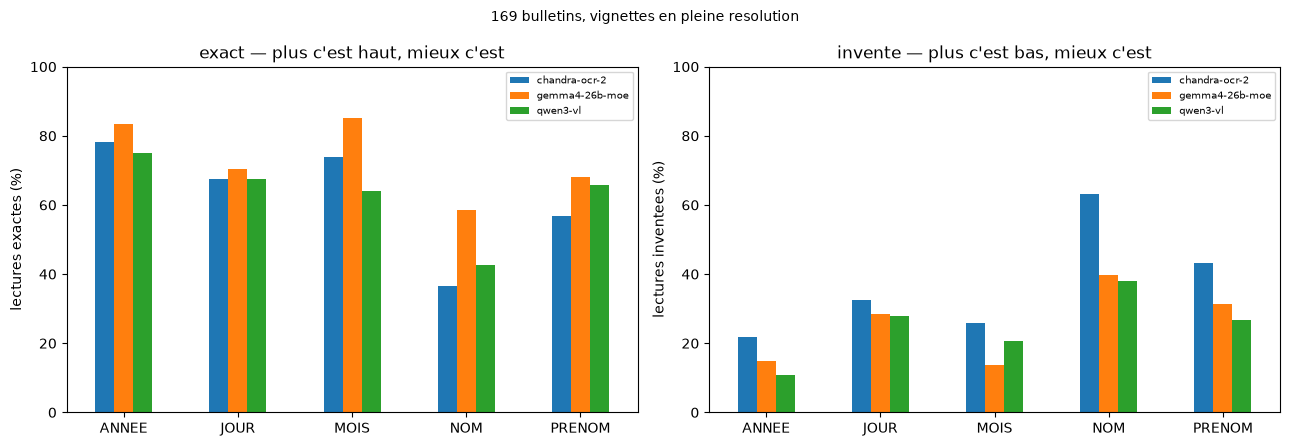

In [80]:
if len(tableau):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    tableau.pivot(index="champ", columns="modele", values="exact_%").plot(
        kind="bar", ax=axes[0])
    axes[0].set_ylabel("lectures exactes (%)")
    axes[0].set_ylim(0, 100)
    axes[0].set_title("exact — plus c'est haut, mieux c'est")
    axes[0].legend(fontsize=7)

    tableau.pivot(index="champ", columns="modele", values="invente_%").plot(
        kind="bar", ax=axes[1], color=None)
    axes[1].set_ylabel("lectures inventees (%)")
    axes[1].set_ylim(0, 100)
    axes[1].set_title("invente — plus c'est bas, mieux c'est")
    axes[1].legend(fontsize=7)

    for ax in axes:
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)

    fig.suptitle(f"{len(ECHANTILLON)} bulletins, vignettes en pleine resolution",
                 fontsize=10)
    plt.tight_layout()
    plt.savefig("banc_bi.png", dpi=150)
    plt.show()

# 10. Regarder les erreurs

In [81]:
CHAMP_A_EXAMINER = "NOM"
MODELE_A_EXAMINER = MODELES[0] if MODELES else None

faux = pd.DataFrame()
if MODELE_A_EXAMINER and MODELE_A_EXAMINER in details_par_modele:
    d = details_par_modele[MODELE_A_EXAMINER]
    faux = d[d[f"etat_{CHAMP_A_EXAMINER}"] == "invente"]
    print(f"{len(faux)} lectures inventees sur {len(d)} pour {CHAMP_A_EXAMINER}\n")
    cols = ["cle", f"lu_{CHAMP_A_EXAMINER}", f"ref_{CHAMP_A_EXAMINER}",
            f"dist_{CHAMP_A_EXAMINER}"]
    display(faux[cols].head(15))

67 lectures inventees sur 169 pour NOM



,cle,lu_NOM,ref_NOM,dist_NOM
3,6901_5300000424,DUVAL HETE,DUVAL,5
4,6901_5300000431,LEBRUN,LEBEAU,3
7,6901_5300000450,ARTAVER,CARTAVET,2
8,6901_5300000452,BUSSARD,BUISSARD,1
10,6901_5300000222,PEREZ JEAN,PEREZ,5
15,6901_5300000298,DONANT,DUPONT,3
16,6901_5300000311,DURIGE,DUNNE,3
20,6901_5300000328,SICOT,SILOT,1
23,6901_5300000340,THAGNOL,STAGNOL,2
24,6901_5300000342,DORANTS,DURAND,3


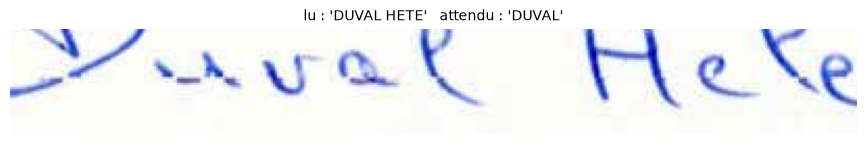

In [82]:
# Voir la vignette d'une lecture fausse, a cote de ce que le modele a lu.
LIGNE = 0

if len(faux) > LIGNE:
    cle = faux.iloc[LIGNE].cle
    idx = ECHANTILLON.index[ECHANTILLON.cle == cle]
    if len(idx):
        v = VIGNETTES[idx[0]][CHAMP_A_EXAMINER]
        fig, ax = plt.subplots(figsize=(11, 11 * v.size[1] / max(v.size[0], 1)))
        ax.imshow(v)
        ax.set_title(f"lu : {faux.iloc[LIGNE][f'lu_{CHAMP_A_EXAMINER}']!r}   "
                     f"attendu : {faux.iloc[LIGNE][f'ref_{CHAMP_A_EXAMINER}']!r}",
                     fontsize=10)
        plt.axis("off")
        plt.show()

In [83]:
# Les bulletins ou aucun modele ne trouve la bonne valeur
if details_par_modele:
    fusion = None
    for modele, d in details_par_modele.items():
        court = modele.replace("/", "_")
        part = d[["cle"] + [f"etat_{c}" for c in CHAMPS]].copy()
        part.columns = ["cle"] + [f"{c}_{court}" for c in CHAMPS]
        fusion = part if fusion is None else fusion.merge(part, on="cle", how="outer")

    for champ in CHAMPS:
        cols = [c for c in fusion.columns if c.startswith(f"{champ}_")]
        aucun = fusion[(fusion[cols] != "exact").all(axis=1)]
        print(f"{champ:8} : {len(aucun)} bulletins ou aucun modele ne trouve la bonne valeur")
    fusion.to_csv("banc_bi_par_bulletin.csv", index=False)
     

NOM      : 57 bulletins ou aucun modele ne trouve la bonne valeur
PRENOM   : 28 bulletins ou aucun modele ne trouve la bonne valeur
JOUR     : 47 bulletins ou aucun modele ne trouve la bonne valeur
MOIS     : 20 bulletins ou aucun modele ne trouve la bonne valeur
ANNEE    : 28 bulletins ou aucun modele ne trouve la bonne valeur


# PARTIE 2: La zone du bloc

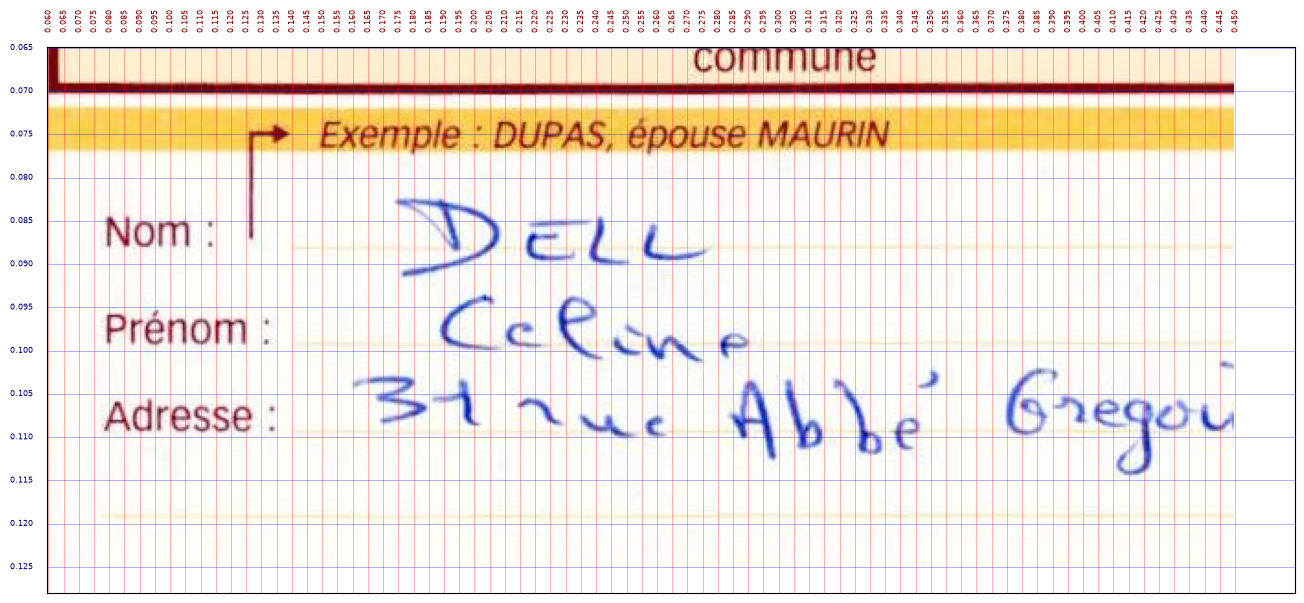

In [86]:
# le cadre jaune du bloc identite
grille(page, x0=0.06, y0=0.065, x1=0.45, y1=0.125, pas=0.005)

bloc — 621 x 146 pixels


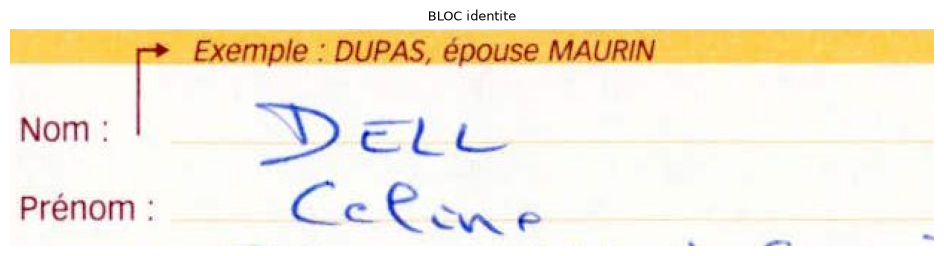

In [90]:

BORDS_BLOC = (0.075, 0.072, 0.450, 0.103)

g, h, d, b = BORDS_BLOC
ZONE_BLOC = (g, h, round(d - g, 4), round(b - h, 4))

v = decouper_frac(page, ZONE_BLOC)
print(f"bloc — {v.size[0]} x {v.size[1]} pixels")
fig, ax = plt.subplots(figsize=(12, 12 * v.size[1] / max(v.size[0], 1)))
ax.imshow(v)
ax.set_title("BLOC identite", fontsize=9)
plt.axis("off")
plt.show()

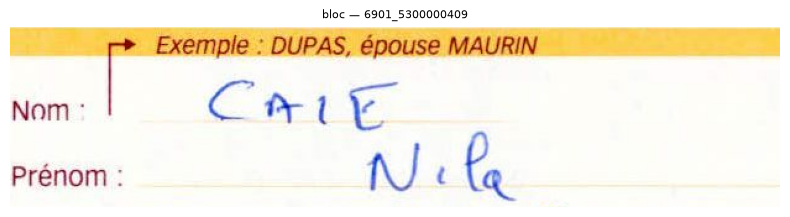

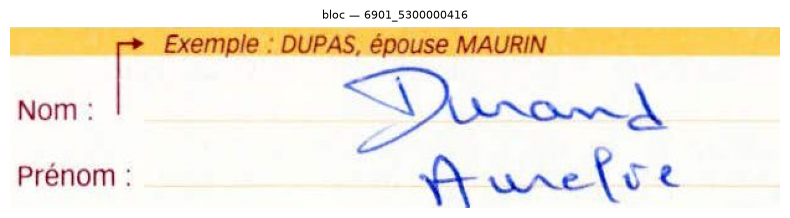

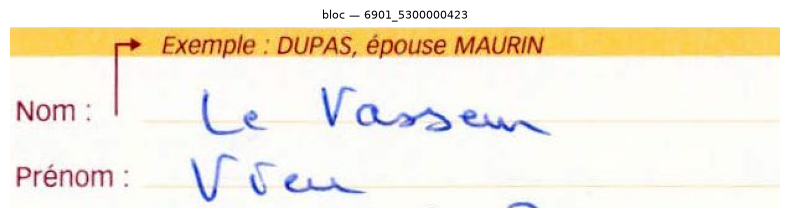

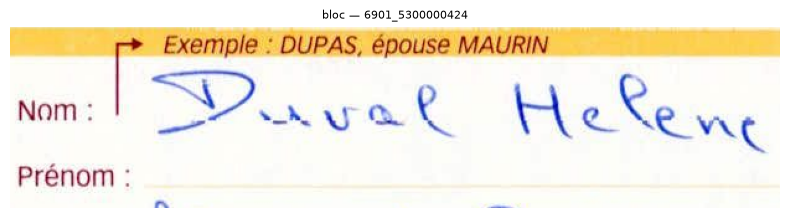

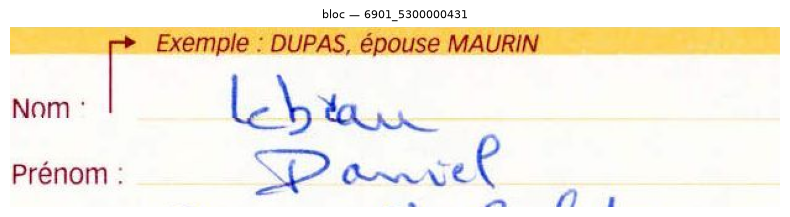

In [91]:
# Verifier sur plusieurs bulletins : c'est justement la tolerance au decalage
# que cette approche est censee apporter.
for i in range(min(5, len(ECHANTILLON))):
    im = charger(ECHANTILLON.chemin[i])
    v = decouper_frac(im, ZONE_BLOC)
    fig, ax = plt.subplots(figsize=(10, 10 * v.size[1] / max(v.size[0], 1)))
    ax.imshow(v)
    ax.set_title(f"bloc — {ECHANTILLON.cle[i]}", fontsize=8)
    plt.axis("off")
    plt.show()

In [93]:

print("colonnes candidates pour l'adresse :")
for c in fq3.columns:
    if c == "cle":
        continue
    v = fq3[c].str.strip()
    v = v[v != ""]
    if len(v) < 20:
        continue
    a_chiffre = v.str.contains(r"\d").mean()
    a_lettre = v.str.contains(r"[A-Za-z]").mean()
    longueur = v.str.len().mean()
    if a_chiffre > 0.5 and a_lettre > 0.5 and longueur > 8:
        print(f"  colonne {c:3} — longueur moyenne {longueur:.0f}, "
              f"{v.nunique()} valeurs distinctes, exemples : {list(v.head(2))}")

colonnes candidates pour l'adresse :


In [94]:
COL_ADRESSE = None      # <-- renseigner, ou laisser None pour ne pas comparer l'adresse

CHAMPS_BLOC = ["NOM", "PRENOM", "ADRESSE"]

REF_BLOC = REFERENCE.copy()
if COL_ADRESSE is not None:
    ref_adr = fq3[["cle", COL_ADRESSE]].copy()
    ref_adr.columns = ["cle", "ref_ADRESSE"]
    ref_adr["ref_ADRESSE"] = ref_adr.ref_ADRESSE.str.strip()
    REF_BLOC = REF_BLOC.merge(ref_adr, on="cle", how="left")
    print("adresse comparable")
else:
    print("adresse lue mais non comparee : COL_ADRESSE non renseignee")

ECHANTILLON_BLOC = ECHANTILLON.drop(
    columns=[c for c in ECHANTILLON.columns if c.startswith("ref_")], errors="ignore"
).merge(REF_BLOC, on="cle", how="inner").reset_index(drop=True)

print(f"{len(ECHANTILLON_BLOC)} bulletins")

adresse lue mais non comparee : COL_ADRESSE non renseignee
169 bulletins


# C. La question posée

In [95]:


PROMPT_BLOC = """Cette image montre un extrait de bulletin individuel du recensement francais.
Elle contient trois lignes manuscrites, chacune precedee de son libelle imprime :
"Nom :", "Prenom :" et "Adresse :".

Transcris ce qui est ecrit a la main sur chacune des trois lignes,
en MAJUSCULES, sans accent.

Regles :
- Ne corrige rien, n'ajoute rien, ne devine pas.
- Ne recopie pas les libelles imprimes, seulement l'ecriture manuscrite.
- Si une ligne n'est pas lisible avec certitude, mets exactement ILLISIBLE pour ce champ.
- Si une ligne est vide, mets une chaine vide.

Reponds uniquement en JSON, sans phrase ni commentaire :
{"NOM": "...", "PRENOM": "...", "ADRESSE": "..."}"""


def extraire_json(texte):
    m = re.search(r"\{.*\}", texte, re.S)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except json.JSONDecodeError:
        return None


print(PROMPT_BLOC[:200], "...")
     


Cette image montre un extrait de bulletin individuel du recensement francais.
Elle contient trois lignes manuscrites, chacune precedee de son libelle imprime :
"Nom :", "Prenom :" et "Adresse :".

Tra ...


# D. Faire passer l'examen

In [97]:

# Les vignettes du bloc, decoupees une seule fois pour tous les modeles.
VIGNETTES_BLOC = [decouper_frac(charger(r.chemin), ZONE_BLOC)
                  for _, r in ECHANTILLON_BLOC.iterrows()]
print(f"{len(VIGNETTES_BLOC)} vignettes preparees")
     

169 vignettes preparees


In [98]:
def passer_examen_bloc(modele):
    """Lit les trois champs d'un coup. Renvoie (details, resume)."""
    lignes = []
    t0 = time.time()
    n_appels = 0

    for i, r in ECHANTILLON_BLOC.iterrows():
        ligne = {"cle": r.cle, "modele": modele}
        try:
            brut_rep = demander(VIGNETTES_BLOC[i], PROMPT_BLOC, modele, max_tokens=250)
            n_appels += 1
            rep = extraire_json(brut_rep) or {}
            if not rep:
                ligne["brut"] = brut_rep[:150]
        except Exception as e:
            rep = {}
            ligne["erreur"] = f"{type(e).__name__}: {e}"

        for champ in CHAMPS_BLOC:
            ref = r.get(f"ref_{champ}", None)
            lu = rep.get(champ, "")
            ligne[f"lu_{champ}"] = lu
            if ref is None or (isinstance(ref, float) and pd.isna(ref)):
                ligne[f"etat_{champ}"] = "sans_reference"
                ligne[f"dist_{champ}"] = np.nan
                ligne[f"len_{champ}"] = np.nan
            else:
                ligne[f"ref_{champ}"] = ref
                ligne[f"etat_{champ}"] = classer(lu, ref)
                ligne[f"dist_{champ}"] = distance(normaliser(lu), normaliser(ref))
                ligne[f"len_{champ}"] = len(normaliser(ref))
        lignes.append(ligne)
        if (i + 1) % 20 == 0:
            print(f"  {i + 1}/{len(ECHANTILLON_BLOC)} — {time.time() - t0:.0f} s")

    duree = time.time() - t0
    details = pd.DataFrame(lignes)

    resume = {"modele": modele, "approche": "bloc",
              "secondes_par_bulletin": duree / max(len(details), 1),
              "secondes_par_champ": duree / max(n_appels * len(CHAMPS_BLOC), 1),
              "N_bulletins": len(details)}
    for champ in CHAMPS_BLOC:
        etats = details[f"etat_{champ}"]
        compares = details[etats != "sans_reference"]
        if not len(compares):
            continue
        e = compares[f"etat_{champ}"]
        resume[f"{champ}_exact"] = (e == "exact").mean()
        resume[f"{champ}_illisible"] = (e == "illisible").mean()
        resume[f"{champ}_invente"] = (e == "invente").mean()
        lisibles = compares[e != "illisible"]
        total = lisibles[f"len_{champ}"].sum()
        resume[f"{champ}_cer"] = (lisibles[f"dist_{champ}"].sum() / total
                                  if total else float("nan"))
    return details, resume

In [99]:
import mlflow

mlflow.set_experiment("fiqual-banc-essai")

resultats_bloc = []
details_bloc = {}

for modele in MODELES:
    print("\n" + "=" * 60)
    print(modele, "— approche bloc")
    print("=" * 60)
    try:
        d, r = passer_examen_bloc(modele)
        details_bloc[modele] = d
        resultats_bloc.append(r)

        with mlflow.start_run(run_name=f"bi-bloc-{modele}-N{len(d)}"):
            mlflow.log_params({"modele": modele, "approche": "bloc entier",
                               "mode": "service interne", "campagne": CAMPAGNE,
                               "zone": "BI", "N": len(d),
                               "champs": ",".join(CHAMPS_BLOC),
                               "zone_bloc": str(ZONE_BLOC)})
            mlflow.log_metrics({k: float(v) for k, v in r.items()
                                if k not in ("modele", "approche") and pd.notna(v)})
            mlflow.log_text(PROMPT_BLOC, "prompt_bloc.txt")
            f = f"details_bloc_{modele.replace('/', '_')}.csv"
            d.to_csv(f, index=False)
            mlflow.log_artifact(f)

        for champ in CHAMPS_BLOC:
            if f"{champ}_exact" in r:
                print(f"  {champ:8} exact {r[f'{champ}_exact']:.0%} | "
                      f"illisible {r[f'{champ}_illisible']:.0%} | "
                      f"invente {r[f'{champ}_invente']:.0%}")
        print(f"  {r['secondes_par_bulletin']:.1f} s par bulletin")
    except Exception as e:
        print("ECHEC :", type(e).__name__, e)
        resultats_bloc.append({"modele": modele, "approche": "bloc",
                               "erreur": f"{type(e).__name__}: {e}"})

print("\ncampagne bloc terminee")


gemma4-26b-moe — approche bloc
  20/169 — 11 s
  40/169 — 22 s
  60/169 — 33 s
  80/169 — 45 s
  100/169 — 58 s
  120/169 — 69 s
  140/169 — 80 s
  160/169 — 92 s
🏃 View run bi-bloc-gemma4-26b-moe-N169 at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1/runs/eb92e9dfe2da4d058492841eaf0d32f5
🧪 View experiment at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1
  NOM      exact 82% | illisible 1% | invente 17%
  PRENOM   exact 88% | illisible 2% | invente 10%
  0.6 s par bulletin

qwen3-vl — approche bloc
  20/169 — 15 s
  40/169 — 31 s
  60/169 — 46 s
  80/169 — 62 s
  100/169 — 77 s
  120/169 — 92 s
  140/169 — 108 s
  160/169 — 123 s
🏃 View run bi-bloc-qwen3-vl-N169 at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1/runs/a233696e5f814b05bc2e6eb13a6947b1
🧪 View experiment at: https://user-farisazibert-mlflow.user.lab.sspcloud.fr/#/experiments/1
  NOM      exact 75% | illisible 0% | invente 25%
  PRENOM   exact 82% | il

# E. Zones séparées contre bloc entier

In [100]:
def aplatir(resultats, approche, champs):
    lignes = []
    for r in resultats:
        if "erreur" in r:
            continue
        for champ in champs:
            if f"{champ}_exact" not in r or pd.isna(r.get(f"{champ}_exact")):
                continue
            lignes.append({
                "modele": r["modele"], "approche": approche, "champ": champ,
                "exact_%": round(r[f"{champ}_exact"] * 100, 1),
                "illisible_%": round(r[f"{champ}_illisible"] * 100, 1),
                "invente_%": round(r[f"{champ}_invente"] * 100, 1),
                "CER_%": (round(r[f"{champ}_cer"] * 100, 1)
                          if pd.notna(r.get(f"{champ}_cer")) else None),
            })
    return lignes


comparatif = pd.DataFrame(
    aplatir(resultats, "zones separees", list(CHAMPS))
    + aplatir(resultats_bloc, "bloc entier", CHAMPS_BLOC)
)
comparatif.to_csv("comparaison_zones_vs_bloc.csv", index=False)
comparatif.sort_values(["champ", "modele", "approche"])

,modele,approche,champ,exact_%,illisible_%,invente_%,CER_%
14,chandra-ocr-2,zones separees,ANNEE,78.1,0.0,21.9,10.8
4,gemma4-26b-moe,zones separees,ANNEE,83.4,1.8,14.8,7.6
9,qwen3-vl,zones separees,ANNEE,75.1,14.2,10.7,4.2
12,chandra-ocr-2,zones separees,JOUR,67.5,0.0,32.5,18.8
2,gemma4-26b-moe,zones separees,JOUR,70.4,1.2,28.4,16.3
7,qwen3-vl,zones separees,JOUR,67.5,4.7,27.8,14.6
13,chandra-ocr-2,zones separees,MOIS,74.0,0.0,26.0,17.3
3,gemma4-26b-moe,zones separees,MOIS,85.2,1.2,13.6,8.9
8,qwen3-vl,zones separees,MOIS,63.9,15.4,20.7,15.0
19,chandra-ocr-2,bloc entier,NOM,66.3,1.2,32.5,13.7


In [101]:


# Le gain, champ par champ et modele par modele
communs = [c for c in CHAMPS_BLOC if c in CHAMPS]
if communs and len(comparatif):
    piv = comparatif[comparatif.champ.isin(communs)].pivot_table(
        index=["champ", "modele"], columns="approche", values="exact_%")
    if {"bloc entier", "zones separees"} <= set(piv.columns):
        piv["gain"] = (piv["bloc entier"] - piv["zones separees"]).round(1)
    display(piv)
     


approche               bloc entier  zones separees  gain
champ  modele                                           
NOM    chandra-ocr-2          66.3            36.7  29.6
       gemma4-26b-moe         82.2            58.6  23.6
       qwen3-vl               74.6            42.6  32.0
PRENOM chandra-ocr-2          79.9            56.8  23.1
       gemma4-26b-moe         88.2            68.0  20.2
       qwen3-vl               81.7            65.7  16.0

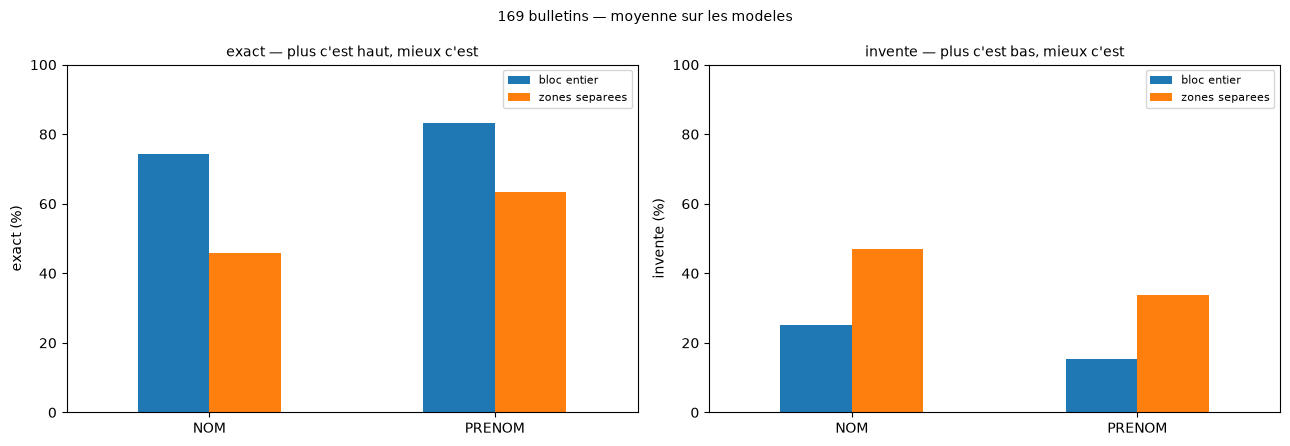

In [102]:
if len(comparatif):
    communs = [c for c in CHAMPS_BLOC if c in CHAMPS]
    sous = comparatif[comparatif.champ.isin(communs)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, mesure, titre in [
            (axes[0], "exact_%", "exact — plus c'est haut, mieux c'est"),
            (axes[1], "invente_%", "invente — plus c'est bas, mieux c'est")]:
        sous.pivot_table(index="champ", columns="approche", values=mesure).plot(
            kind="bar", ax=ax)
        ax.set_ylabel(mesure.replace("_%", " (%)"))
        ax.set_ylim(0, 100)
        ax.set_title(titre, fontsize=10)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)
        ax.legend(fontsize=8)

    fig.suptitle(f"{len(ECHANTILLON_BLOC)} bulletins — moyenne sur les modeles",
                 fontsize=10)
    plt.tight_layout()
    plt.savefig("zones_vs_bloc.png", dpi=150)
    plt.show()

# F. Le piège à vérifier : l'inversion

In [104]:
for modele, d in details_bloc.items():
    if "ref_NOM" not in d.columns or "ref_PRENOM" not in d.columns:
        continue
    inverses = d[
        (d.lu_NOM.map(normaliser) == d.ref_PRENOM.map(normaliser))
        & (d.lu_PRENOM.map(normaliser) == d.ref_NOM.map(normaliser))
        & (d.ref_NOM.map(normaliser) != "")
    ]
    print(f"{modele:22} {len(inverses)} inversions nom/prenom sur {len(d)}")
    if len(inverses):
        display(inverses[["cle", "lu_NOM", "ref_NOM", "lu_PRENOM", "ref_PRENOM"]].head(5))

gemma4-26b-moe         0 inversions nom/prenom sur 169
qwen3-vl               0 inversions nom/prenom sur 169
chandra-ocr-2          0 inversions nom/prenom sur 169


29 lectures inventees pour NOM


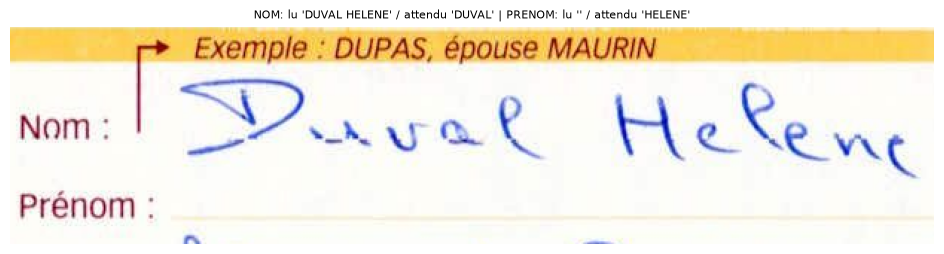

In [106]:
#Regarder une erreur a l'oeil, avec ce que le modele a lu
MODELE_BLOC = MODELES[0] if MODELES else None
CHAMP_BLOC = "NOM"
LIGNE_BLOC = 0

if MODELE_BLOC in details_bloc:
    d = details_bloc[MODELE_BLOC]
    faux_bloc = d[d[f"etat_{CHAMP_BLOC}"] == "invente"]
    print(f"{len(faux_bloc)} lectures inventees pour {CHAMP_BLOC}")
    if len(faux_bloc) > LIGNE_BLOC:
        l = faux_bloc.iloc[LIGNE_BLOC]
        idx = ECHANTILLON_BLOC.index[ECHANTILLON_BLOC.cle == l.cle]
        if len(idx):
            v = VIGNETTES_BLOC[idx[0]]
            fig, ax = plt.subplots(figsize=(12, 12 * v.size[1] / max(v.size[0], 1)))
            ax.imshow(v)
            titre = " | ".join(
                f"{c}: lu {l.get(f'lu_{c}', '')!r} / attendu {l.get(f'ref_{c}', '')!r}"
                for c in CHAMPS_BLOC if f"ref_{c}" in l.index)
            ax.set_title(titre, fontsize=8)
            plt.axis("off")
            plt.show()